In [11]:
import numpy as np, pandas as pd
from matplotlib.pyplot import subplots
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.api import OLS
from ISLP import load_data
from ISLP.models import (summarize, Stepwise, poly, ModelSpec as MS)
from ISLP.models import sklearn_sm
from sklearn.model_selection import cross_validate, KFold

In [12]:
from ISLP.transforms import (BSpline, NaturalSpline)
from ISLP.models import bs, ns

In [13]:
Auto=load_data('Auto')
horsepower=Auto['horsepower']
mpg=Auto['mpg']

array([[<Axes: xlabel='mpg', ylabel='mpg'>,
        <Axes: xlabel='cylinders', ylabel='mpg'>,
        <Axes: xlabel='displacement', ylabel='mpg'>,
        <Axes: xlabel='horsepower', ylabel='mpg'>,
        <Axes: xlabel='weight', ylabel='mpg'>,
        <Axes: xlabel='acceleration', ylabel='mpg'>,
        <Axes: xlabel='year', ylabel='mpg'>,
        <Axes: xlabel='origin', ylabel='mpg'>],
       [<Axes: xlabel='mpg', ylabel='cylinders'>,
        <Axes: xlabel='cylinders', ylabel='cylinders'>,
        <Axes: xlabel='displacement', ylabel='cylinders'>,
        <Axes: xlabel='horsepower', ylabel='cylinders'>,
        <Axes: xlabel='weight', ylabel='cylinders'>,
        <Axes: xlabel='acceleration', ylabel='cylinders'>,
        <Axes: xlabel='year', ylabel='cylinders'>,
        <Axes: xlabel='origin', ylabel='cylinders'>],
       [<Axes: xlabel='mpg', ylabel='displacement'>,
        <Axes: xlabel='cylinders', ylabel='displacement'>,
        <Axes: xlabel='displacement', ylabel='displacement

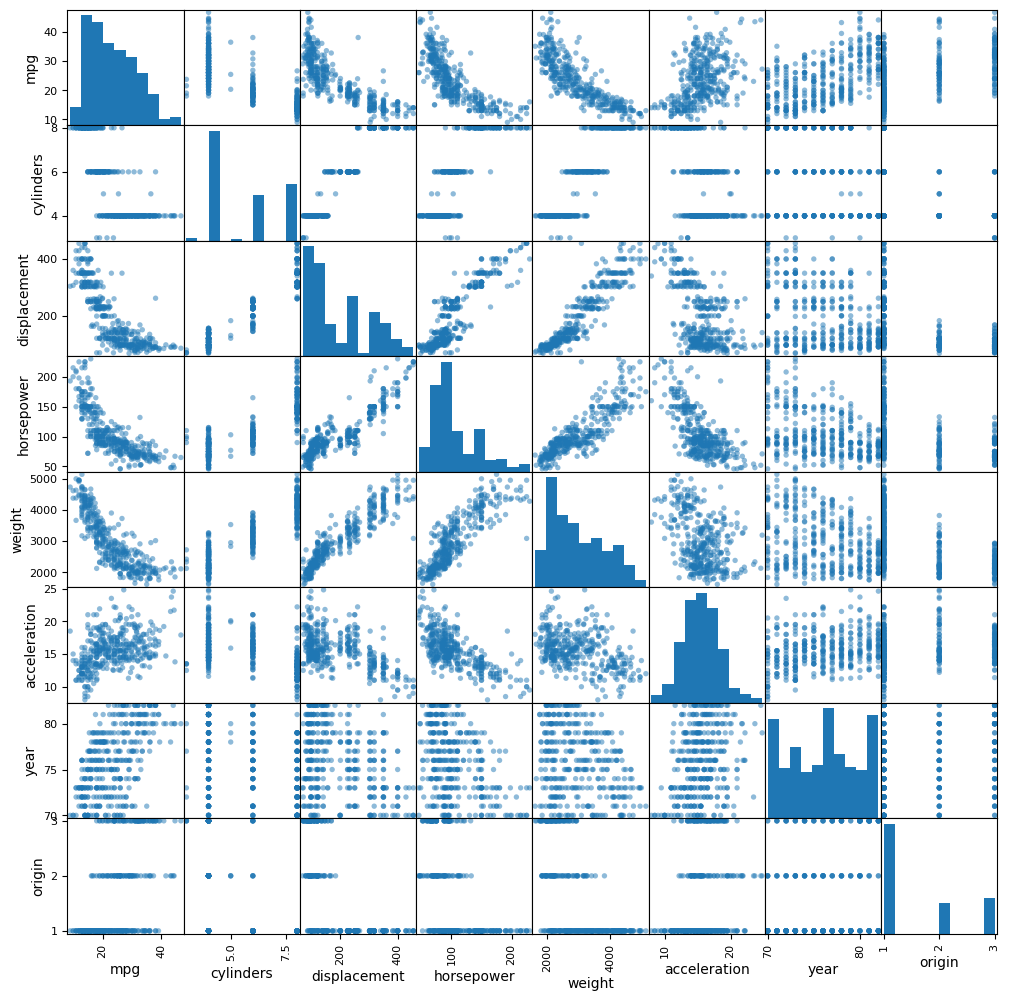

In [14]:
pd.plotting.scatter_matrix(Auto, figsize=(12,12), marker = 'o', hist_kwds = {'bins': 10}, s = 15, alpha = 0.5)

In [15]:
Auto.corr()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
mpg,1.000000,-0.777618,-0.805127,-0.778427,-0.832244,0.423329,0.580541,0.565209
cylinders,-0.777618,1.000000,0.950823,0.842983,0.897527,-0.504683,-0.345647,-0.568932
displacement,-0.805127,0.950823,1.000000,0.897257,0.932994,-0.543800,-0.369855,-0.614535
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361,-0.455171
weight,-0.832244,0.897527,0.932994,0.864538,1.000000,-0.416839,-0.309120,-0.585005
acceleration,0.423329,-0.504683,-0.543800,-0.689196,-0.416839,1.000000,0.290316,0.212746
year,0.580541,-0.345647,-0.369855,-0.416361,-0.309120,0.290316,1.000000,0.181528
origin,0.565209,-0.568932,-0.614535,-0.455171,-0.585005,0.212746,0.181528,1.000000


In [16]:
cv_error = np.zeros(11)
Hm = np.array(horsepower)
M = sklearn_sm(sm.OLS)
#Let's introduce splits. 
cv = KFold(n_splits=5,shuffle=True,random_state=0)
for i, d in enumerate(range(1,12)):
    Xcrossm = np.power.outer(Hm, np.arange(d+1))
    Mat_CV = cross_validate(M,Xcrossm,mpg,cv=cv)
    cv_error[i] = np.mean(Mat_CV['test_score'])
cv_error

array([24.129309  , 19.16472771, 19.30299359, 19.44988801, 18.98093737,
       18.97643941, 18.8843568 , 22.90555141, 23.02796412, 48.66352886,
       71.59507646])

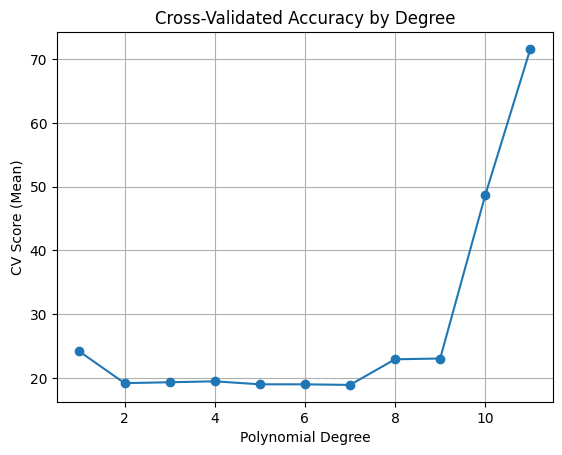

In [17]:
plt.plot(range(1, 12), cv_error, marker='o')
plt.xlabel('Polynomial Degree')
plt.ylabel('CV Score (Mean)')
plt.title('Cross-Validated Accuracy by Degree')
plt.grid(True)
plt.show()

In [18]:
horse_grid = np.linspace(horsepower.min(), horsepower.max(), 100)
horse_df=pd.DataFrame({'horsepower':horse_grid})

In [19]:
def plot_mpg_fit(horse_df, basis, title):
    X1 = basis.transform(Auto)
    Xnew1 = basis.transform(horse_df)
    M = sm.OLS(mpg, X1).fit()
    preds = M.get_prediction(Xnew1)
    bands = preds.conf_int(alpha=0.05)
    fig, ax = subplots(figsize=(8,8))
    ax.scatter(horsepower,mpg,facecolor='gray',alpha=0.5)
    for val, ls in zip([preds.predicted_mean,bands[:,0],bands[:,1]],['b','r--','r--']):
        ax.plot(horse_df.values, val, ls, linewidth=3)
    ax.set_title(title, fontsize=20)
    ax.set_xlabel('Horsepower', fontsize=20)
    ax.set_ylabel('mpg', fontsize=20);
    return ax

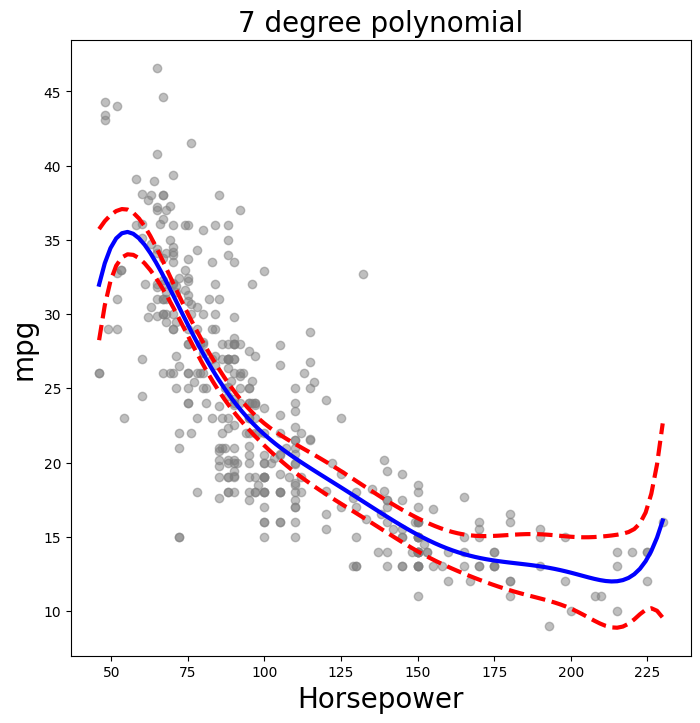

In [20]:
model7=MS([poly('horsepower', degree=7)]).fit(Auto)
plot_mpg_fit(horse_df, model7, '7 degree polynomial');

In [21]:
X1 = model7.transform(Auto)
M = sm.OLS(mpg, X1).fit()
summarize(M)

,coef,std err,t,P>|t|
intercept,23.4459,0.217,108.058,0.000
"poly(horsepower, degree=7)[0]",-120.1377,4.296,-27.966,0.000
"poly(horsepower, degree=7)[1]",44.0895,4.296,10.263,0.000
"poly(horsepower, degree=7)[2]",-3.9488,4.296,-0.919,0.359
"poly(horsepower, degree=7)[3]",-5.1878,4.296,-1.208,0.228
"poly(horsepower, degree=7)[4]",13.2722,4.296,3.089,0.002
"poly(horsepower, degree=7)[5]",-8.5462,4.296,-1.989,0.047
"poly(horsepower, degree=7)[6]",7.9806,4.296,1.858,0.064


In [23]:
cv_error_cuts = np.zeros(20)
for i , d in enumerate(range(1,21)):
    Xcross = pd.qcut(horsepower,d+1)
    M_CV_cut = cross_validate(sklearn_sm(sm.OLS),pd.get_dummies(Xcross),mpg,cv=cv)
    cv_error_cuts[i] = np.mean(M_CV_cut['test_score'])
cv_error_cuts

array([29.82444399, 23.41049429, 20.26054905, 20.94466903, 18.9431238 ,
       19.74372876, 18.83251652, 18.69517885, 19.38914021, 18.70211447,
       17.9802214 , 19.46457473, 19.12644741, 19.03149541, 18.25730498,
       19.42660673, 19.07914753, 19.26482791, 18.92616421, 20.80317346])

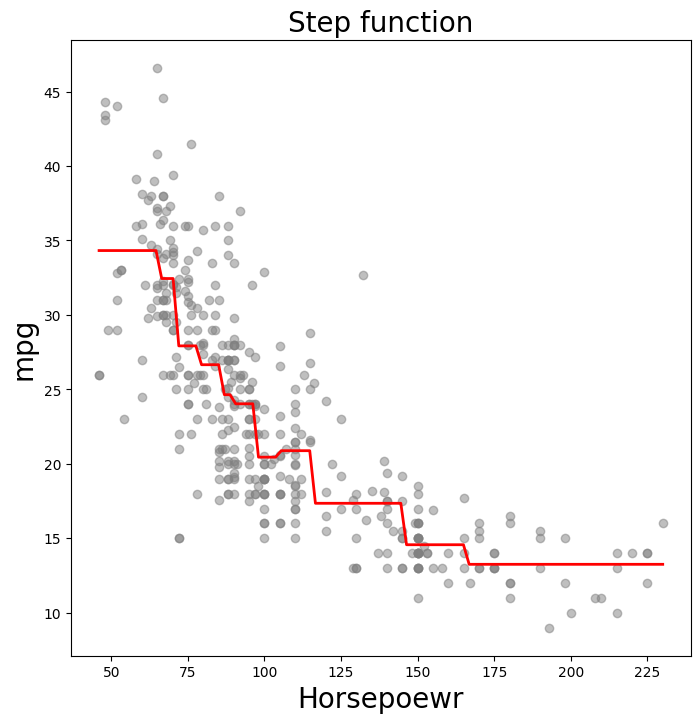

In [26]:
n_cuts = 10
cut_horse = pd.qcut(horsepower, n_cuts + 1)
dummy_horse = pd.get_dummies(cut_horse)
mpg_series = pd.Series(mpg, name='mpg',index = dummy_horse.index)
dfh_step = pd.concat([dummy_horse, mpg_series], axis = 1)
Xnewh = dfh_step.iloc[:,:-1]
ynewh = dfh_step['mpg'].to_numpy()[:, np.newaxis]
Xh =Xnewh.values
resh = sm.OLS(ynewh, Xh).fit()
Xh_grid = np.linspace(horsepower.min(), horsepower.max(),100)
groupsh = pd.cut(Xh_grid, bins=cut_horse.dtype.categories)
dummiesh = pd.get_dummies(groupsh)
yh_step = resh.predict(dummiesh)
fig, ax =plt.subplots(figsize=(8,8))
ax.scatter(horsepower, mpg, facecolor = 'gray', alpha = 0.5)
ax.plot(Xh_grid, yh_step, '-r', linewidth = 2)
ax.set_title('Step function', fontsize = 20)
ax.set_xlabel('Horsepoewr', fontsize = 20)
ax.set_ylabel('mpg', fontsize = 20)
plt.show()

In [27]:
summarize(resh)

,coef,std err,t,P>|t|
x1,34.3243,0.701,48.982,0.0
x2,32.4462,0.683,47.537,0.0
x3,27.9235,0.731,38.198,0.0
x4,26.6583,0.710,37.525,0.0
x5,24.6452,0.658,37.471,0.0
x6,24.0346,0.836,28.751,0.0
x7,20.4524,0.658,31.096,0.0
x8,20.8862,0.792,26.387,0.0
x9,17.3553,0.691,25.099,0.0
x10,14.5722,0.710,20.512,0.0


In [28]:
ns_horse = MS([ns('horsepower', df = 6)]).fit( Auto)
M_nsh = sm.OLS(mpg, ns_horse.transform(Auto)).fit()
summarize(M_nsh)

,coef,std err,t,P>|t|
intercept,34.7379,1.509,23.021,0.0
"ns(horsepower, df=6)[0]",-8.2104,1.594,-5.149,0.0
"ns(horsepower, df=6)[1]",-13.0459,1.835,-7.108,0.0
"ns(horsepower, df=6)[2]",-14.5766,1.886,-7.730,0.0
"ns(horsepower, df=6)[3]",-22.8020,1.624,-14.039,0.0
"ns(horsepower, df=6)[4]",-22.7577,3.512,-6.480,0.0
"ns(horsepower, df=6)[5]",-20.8492,1.742,-11.967,0.0


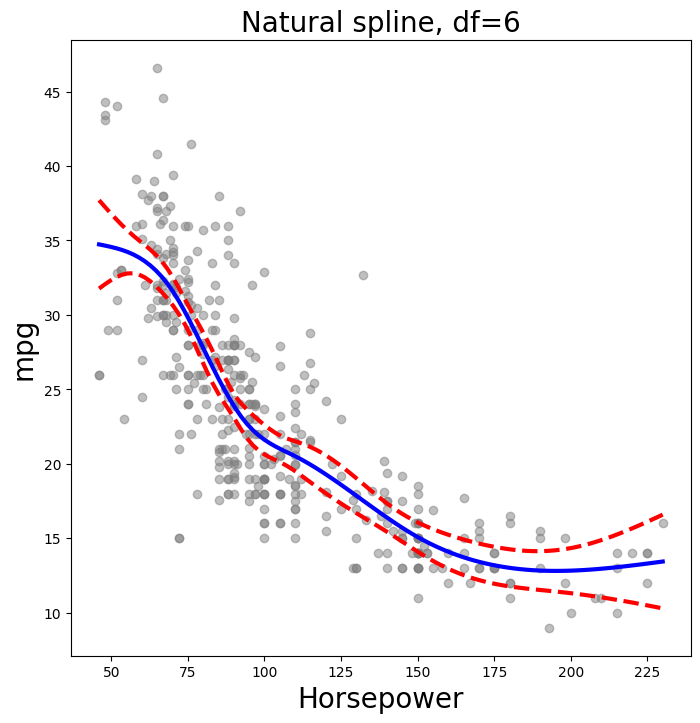

In [29]:
plot_mpg_fit(horse_df, ns_horse,'Natural spline, df=6');

In [30]:
Boston = load_data('Boston')
dis = Boston['dis']
nox = Boston['nox']

In [31]:
model3 = MS([poly('dis', degree = 3)]).fit(Boston)
X=model3.transform(Boston)
res = sm.OLS(nox, X).fit()
summarize(res)

,coef,std err,t,P>|t|
intercept,0.5547,0.003,201.021,0.0
"poly(dis, degree=3)[0]",-2.0031,0.062,-32.271,0.0
"poly(dis, degree=3)[1]",0.8563,0.062,13.796,0.0
"poly(dis, degree=3)[2]",-0.3180,0.062,-5.124,0.0


Text(0, 0.5, 'nox')

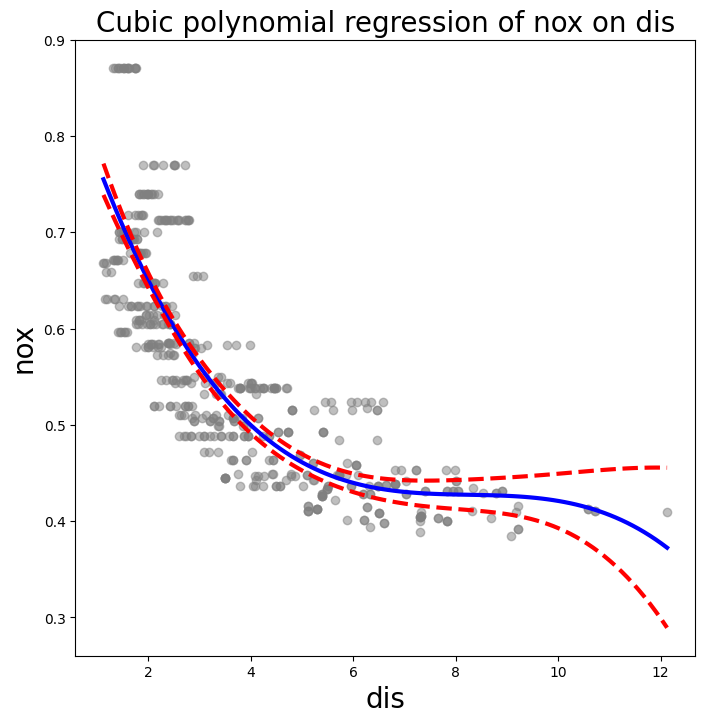

In [35]:
dis_grid = np.linspace(dis.min(), dis.max(), 100)
dis_df = pd.DataFrame({'dis': dis_grid})
dis2_df = pd.DataFrame({'dis':dis})
Xnew2=model3.transform(dis_df)
preds = res.get_prediction(Xnew2)
bands = preds.conf_int(alpha=0.05)
fig, ax = subplots(figsize=(8,8))
ax.scatter(dis,nox,facecolor='gray', alpha=0.5)
for val, ls in zip([preds.predicted_mean,bands[:,0],bands[:,1]],['b','r--','r--']):
        ax.plot(dis_df.values, val, ls, linewidth=3)
ax.set_title('Cubic polynomial regression of nox on dis', fontsize=20)
ax.set_xlabel('dis', fontsize=20)
ax.set_ylabel('nox', fontsize=20)

In [36]:
preds=preds.predicted_mean.reshape(-1,1)
preds.shape

(100, 1)

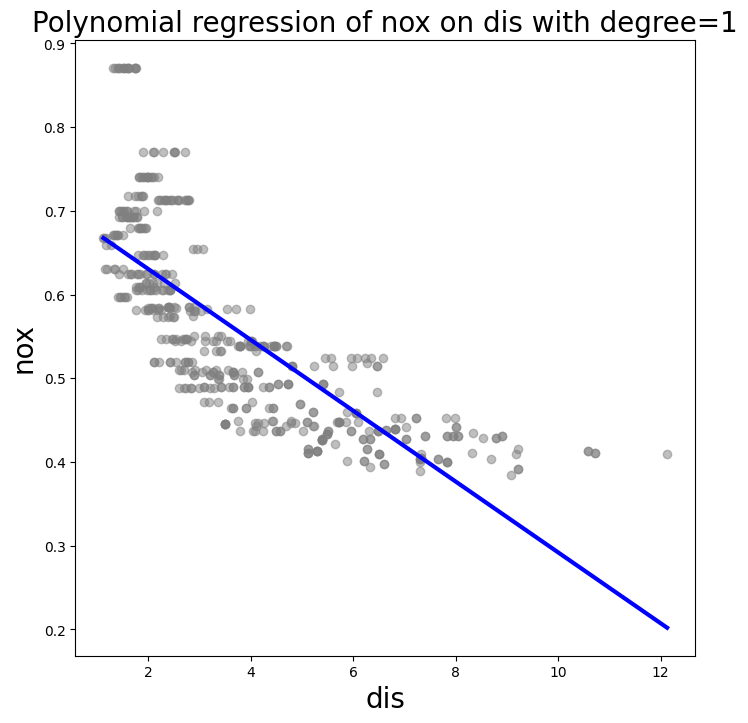

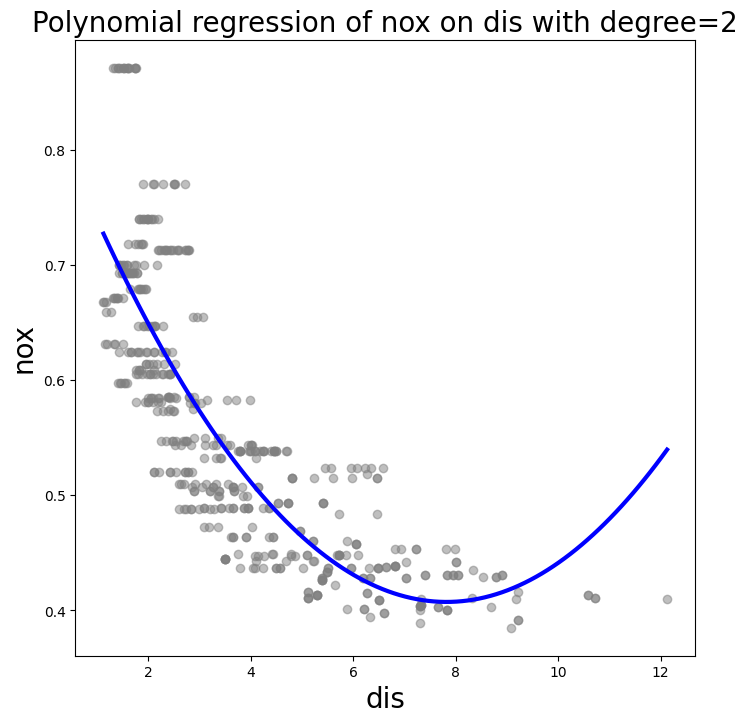

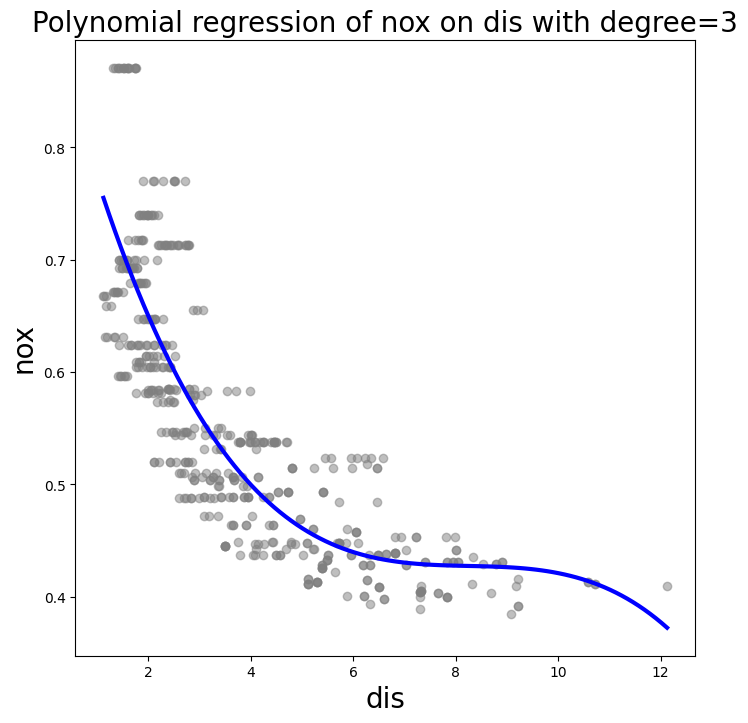

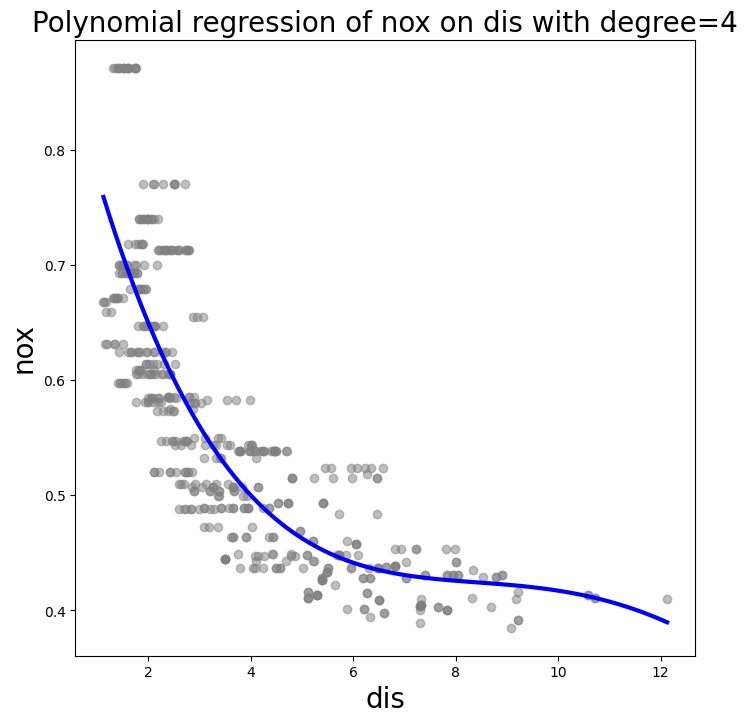

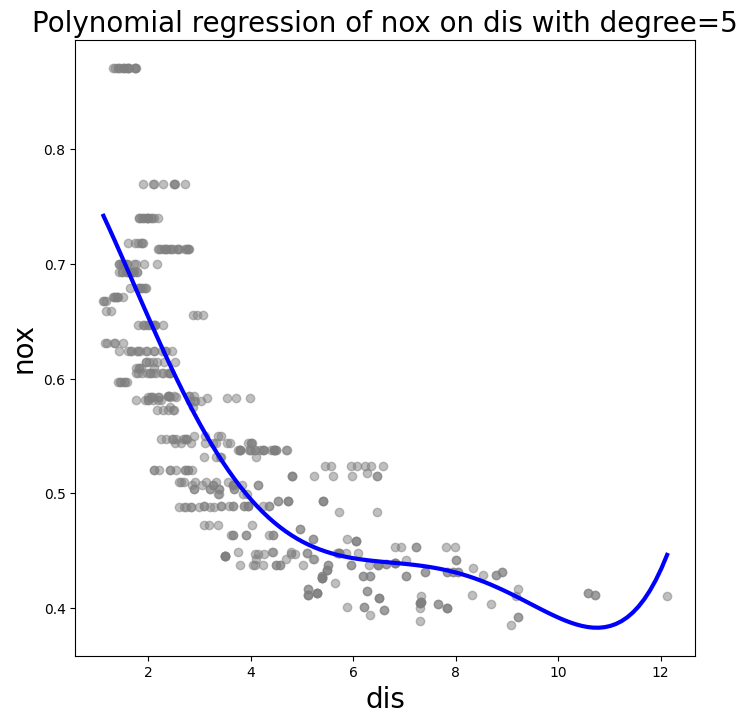

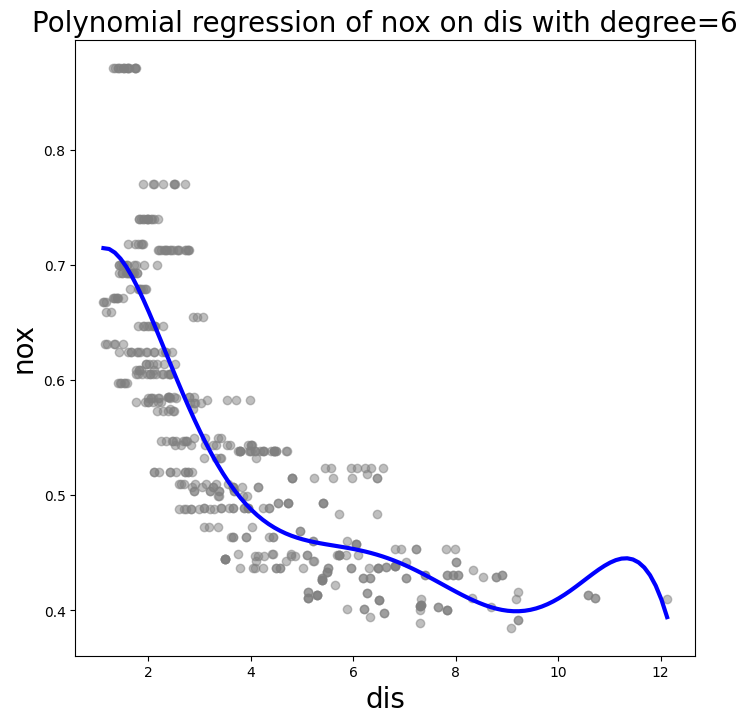

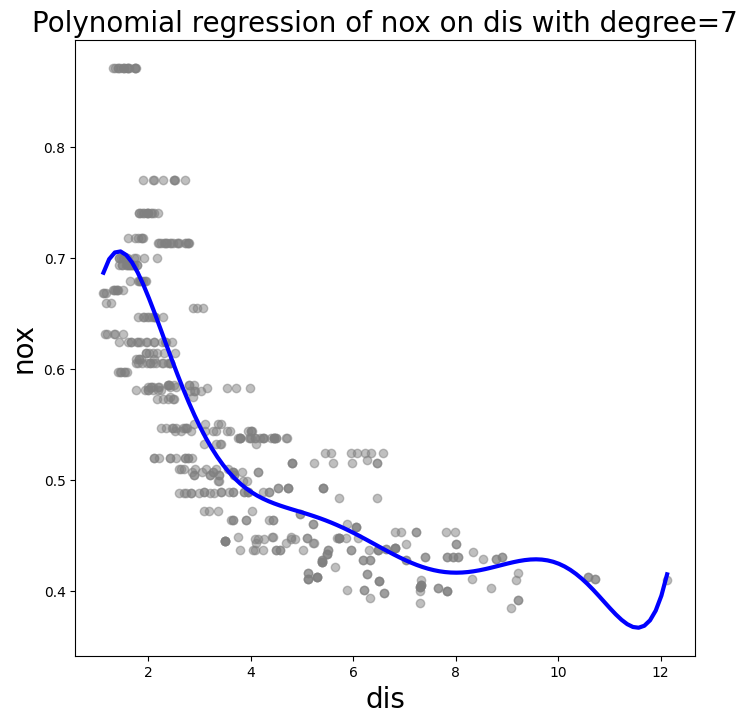

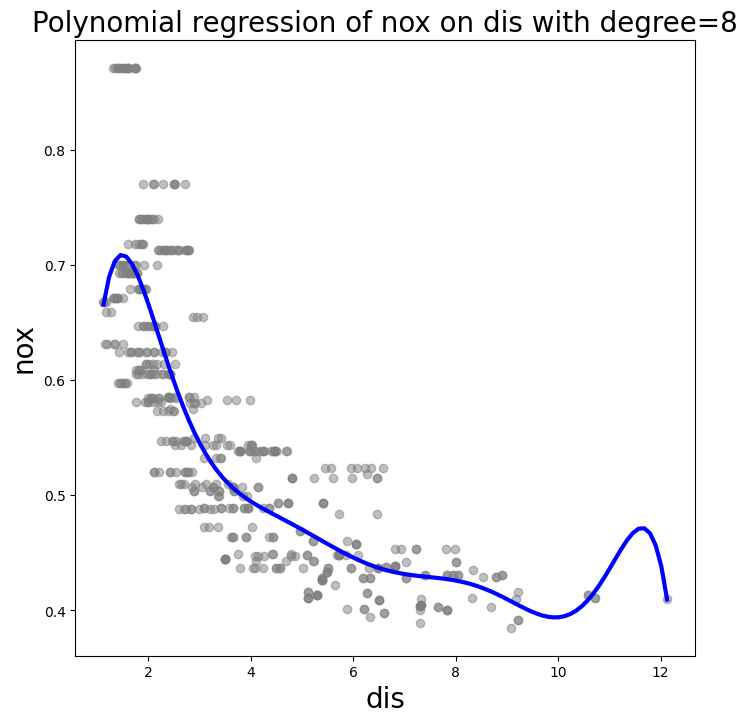

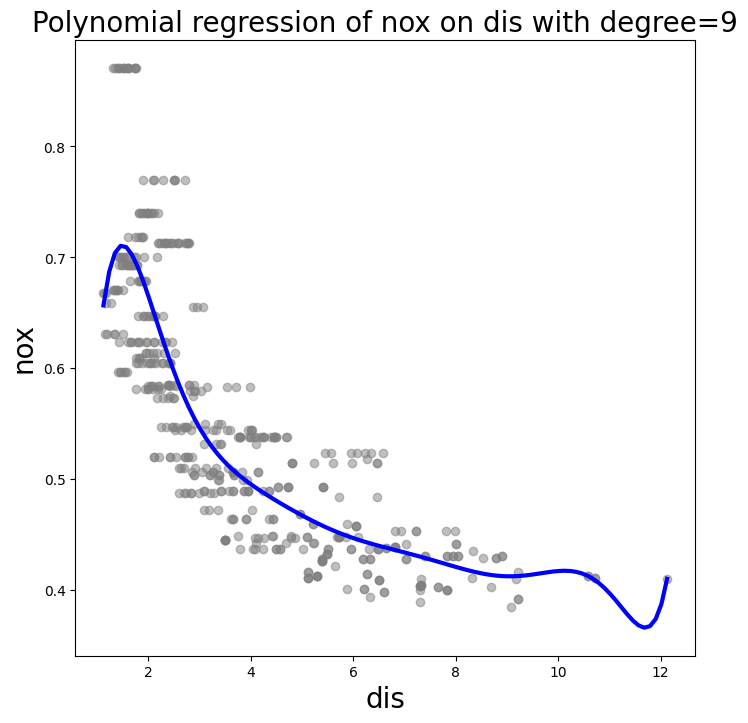

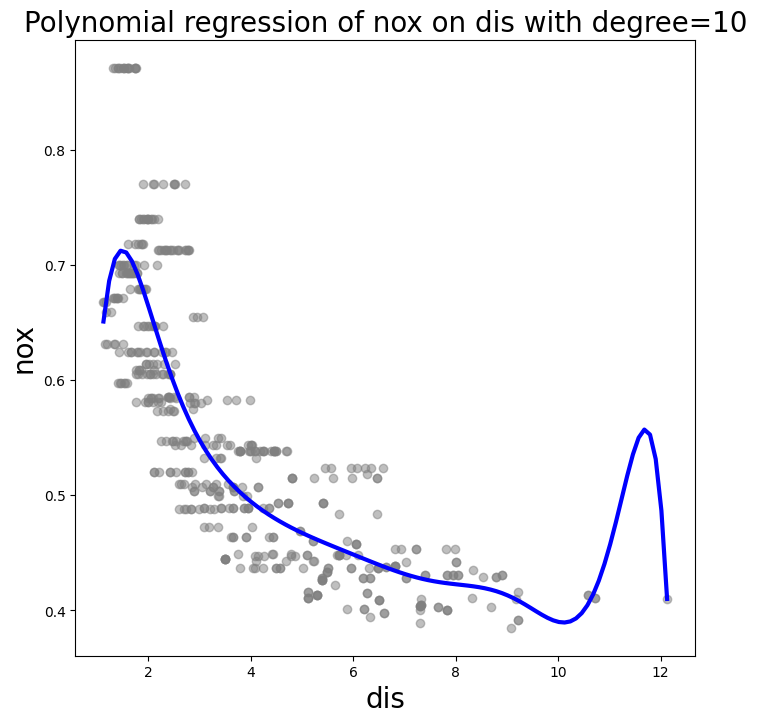

In [38]:
RSS={}
for d in range(1,11):
    model =MS([poly('dis',degree=d)]).fit(Boston)
    X=model.transform(Boston)
    res=sm.OLS(nox,X).fit()
    Xnew=model.transform(dis_df)
    Xnew2=model.transform(dis2_df)
    preds = res.get_prediction(Xnew)
    yhat= res.get_prediction(Xnew2)
    yhat = yhat.predicted_mean
    RSS[d] = np.sum((nox - yhat)**2)
    fig, ax = subplots(figsize=(8,8))
    ax.scatter(dis,nox,facecolor='gray',alpha=0.5)
    ax.plot(dis_df.values,preds.predicted_mean , 'b', linewidth=3)
    ax.set_title('Polynomial regression of nox on dis with degree='+ str(d), fontsize=20)
    ax.set_xlabel('dis', fontsize=20)
    ax.set_ylabel('nox', fontsize=20);

In [39]:
pd.DataFrame(RSS,index=['RSS']).T

,RSS
1,2.768563
2,2.035262
3,1.934107
4,1.932981
5,1.915290
6,1.878257
7,1.849484
8,1.835630
9,1.833331
10,1.832171


In [42]:
cv_error = np.zeros(11)
H = np.array(dis)
M = sklearn_sm(sm.OLS)
cv = KFold(n_splits=5,shuffle=True,random_state=0)
for i, d in enumerate(range(1,12)):
    Xcross = np.power.outer(H, np.arange(d+1))
    Mat_CV = cross_validate(M,Xcross,nox,cv=cv)
    cv_error[i] = np.mean(Mat_CV['test_score'])
cv_error

array([0.00550455, 0.00404589, 0.00384482, 0.00385288, 0.00405327,
       0.00490166, 0.00711742, 0.00654051, 0.02188359, 0.00468514,
       0.05257745])

In [43]:
bs_dis = MS([bs('dis', df=4)]).fit(Boston)
M_bs = sm.OLS(nox, bs_dis.transform(Boston)).fit()
summarize(M_bs)

,coef,std err,t,P>|t|
intercept,0.7345,0.015,50.306,0.000
"bs(dis, df=4)[0]",-0.0581,0.022,-2.658,0.008
"bs(dis, df=4)[1]",-0.4636,0.024,-19.596,0.000
"bs(dis, df=4)[2]",-0.1998,0.043,-4.634,0.000
"bs(dis, df=4)[3]",-0.3888,0.046,-8.544,0.000


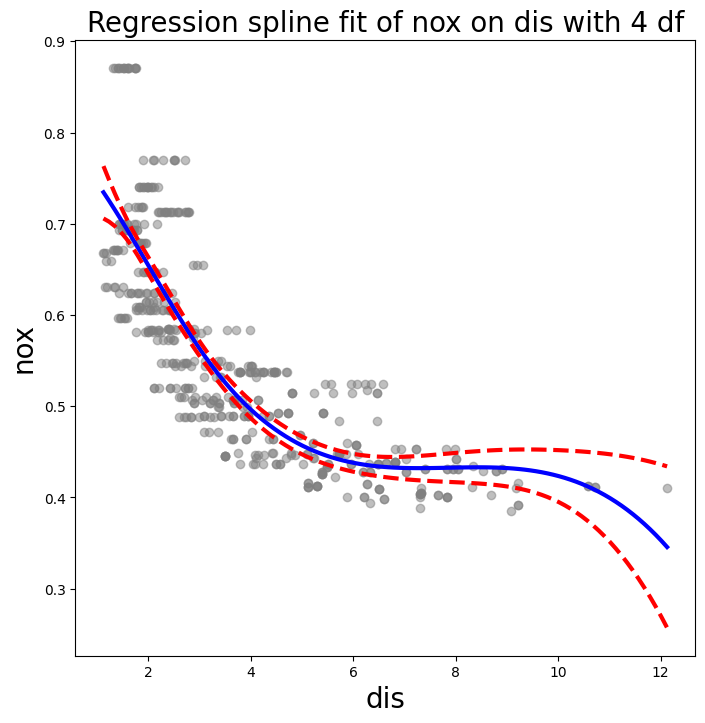

In [44]:
X = bs_dis.transform(Boston)
Xnew = bs_dis.transform(dis_df)
M = sm.OLS(nox, X).fit()
preds = M.get_prediction(Xnew)
bands = preds.conf_int(alpha=0.05)
fig, ax = subplots(figsize=(8,8))
ax.scatter(dis,nox,facecolor='gray',alpha=0.5)
for val, ls in zip([preds.predicted_mean,bands[:,0],bands[:,1]],['b','r--','r--']):
        ax.plot(dis_df.values, val, ls, linewidth=3)
ax.set_title('Regression spline fit of nox on dis with 4 df', fontsize=20)
ax.set_xlabel('dis', fontsize=20)
ax.set_ylabel('nox', fontsize=20);

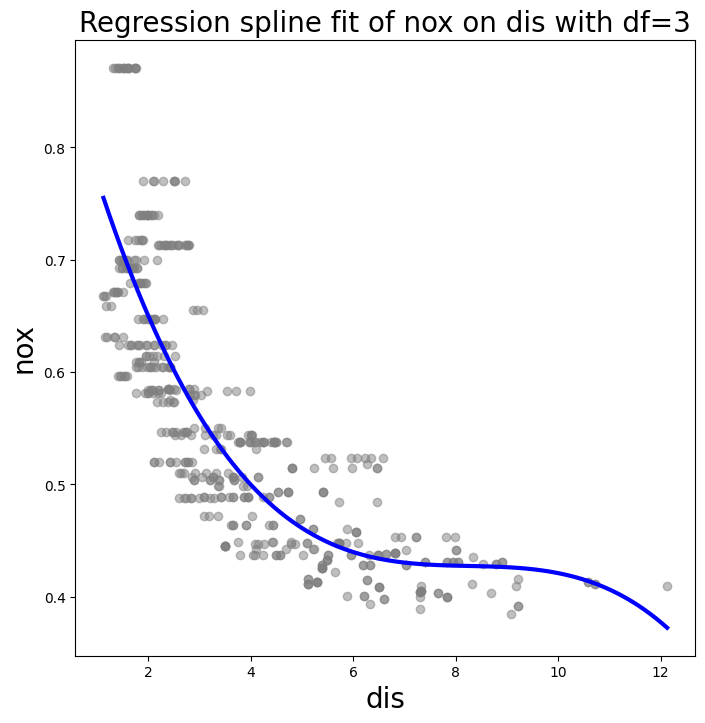

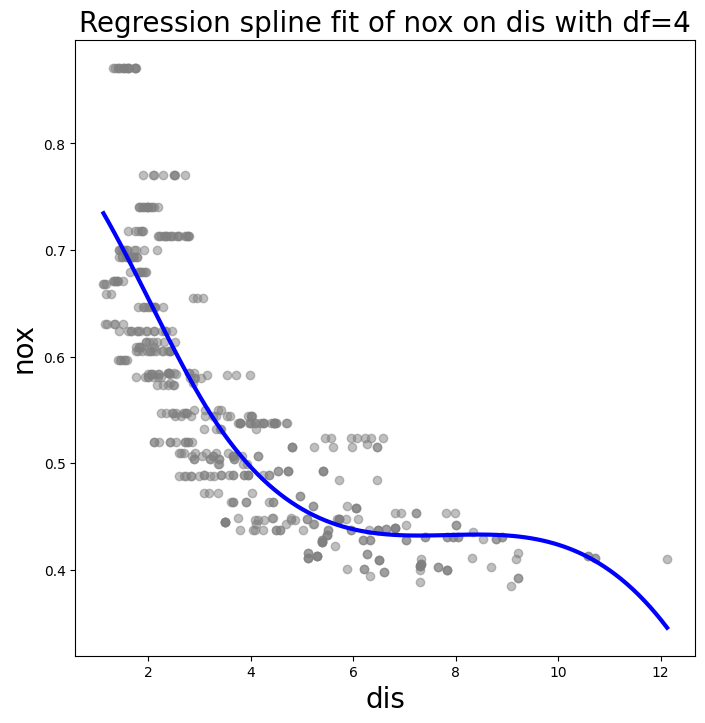

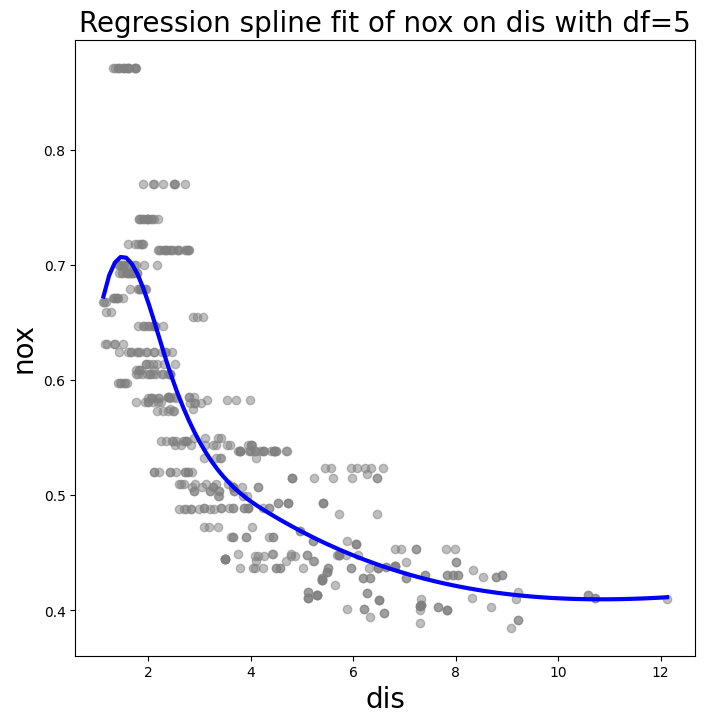

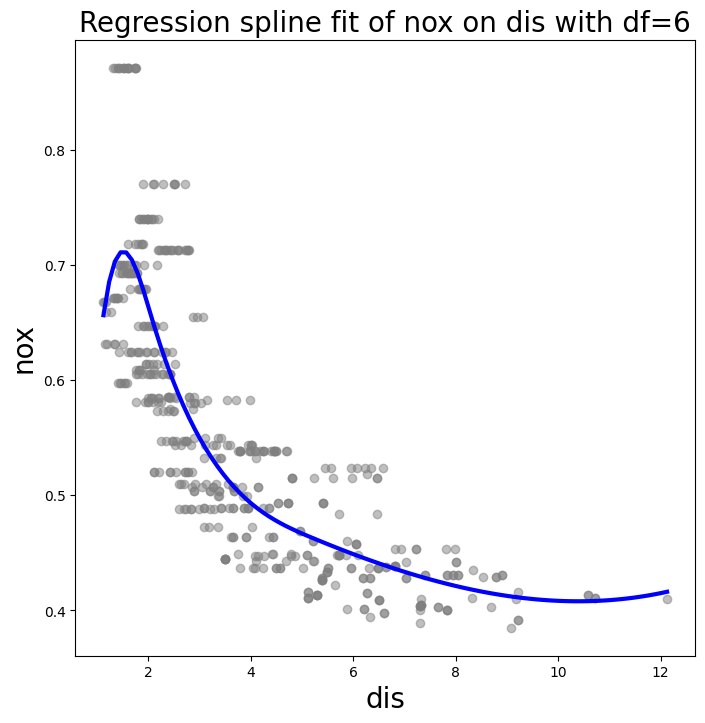

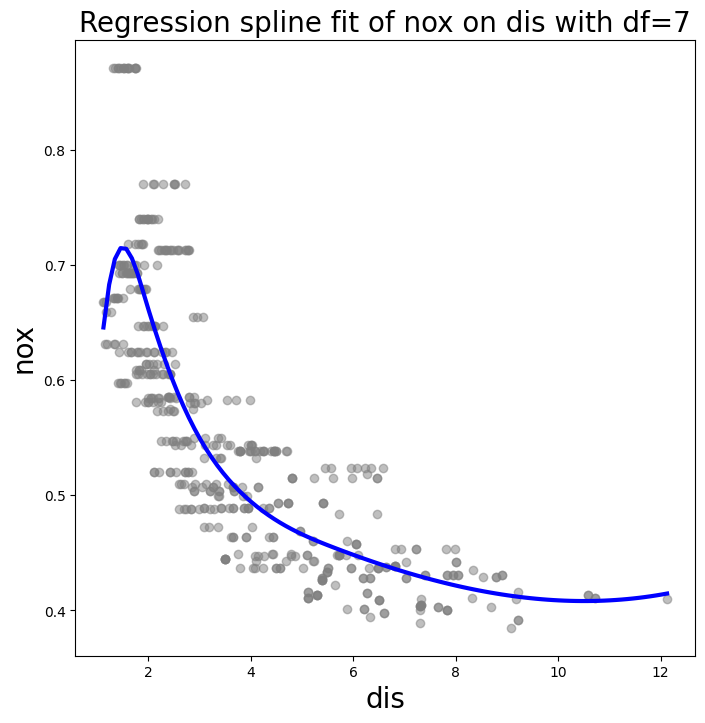

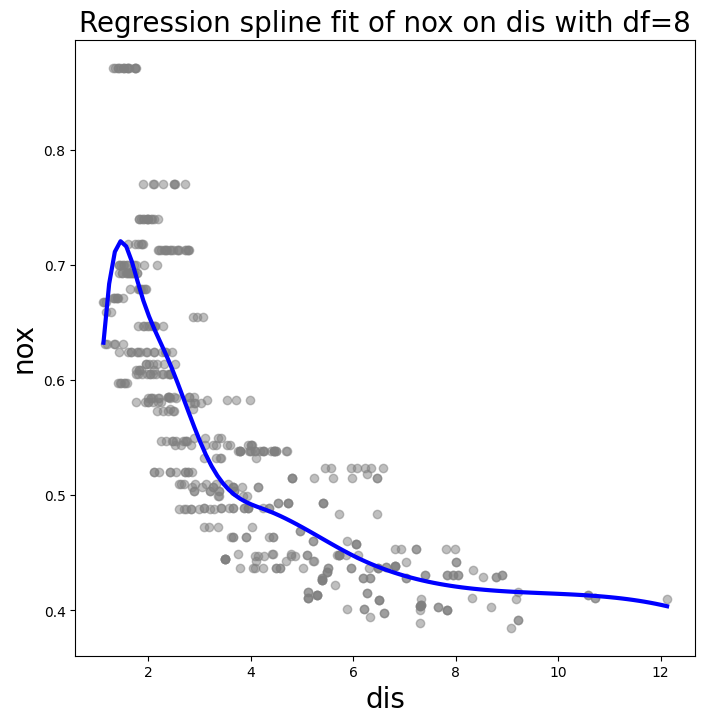

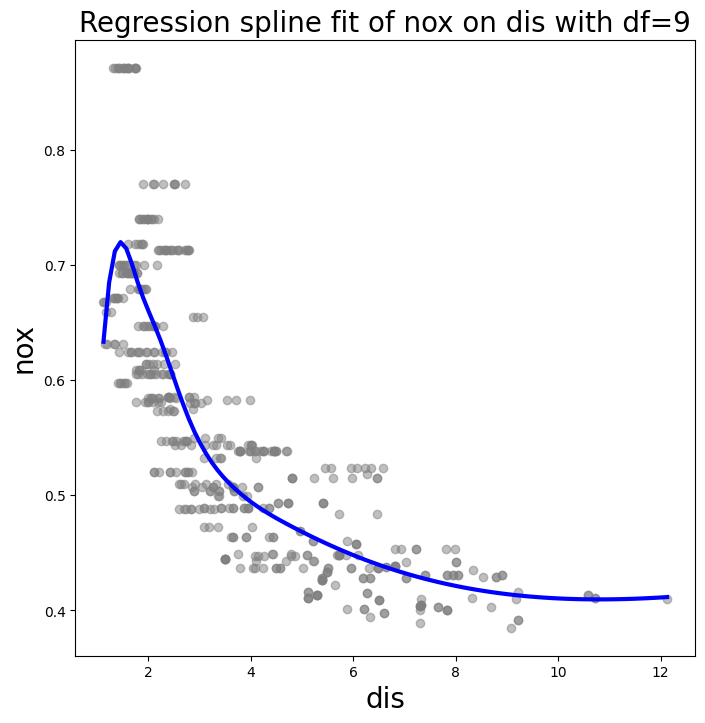

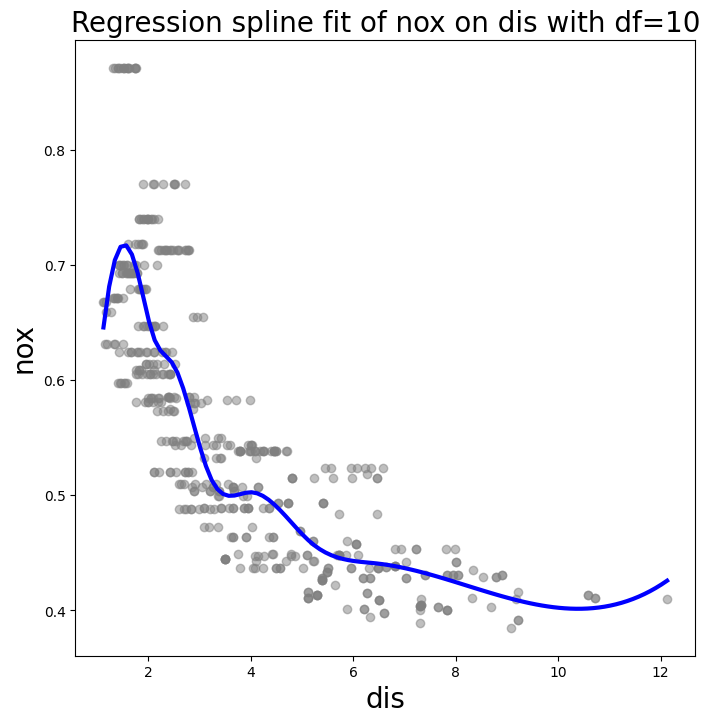

In [45]:
RSS={}
for d in range(3,11):
    bs_dis = MS([bs('dis', df=d)]).fit(Boston)
    M_bs = sm.OLS(nox, bs_dis.transform(Boston)).fit()
    Xnew = bs_dis.transform(dis_df)
    Xnew2=bs_dis.transform(dis2_df)
    preds = M_bs.get_prediction(Xnew)
    yhat=M_bs.get_prediction(Xnew2)
    yhat=yhat.predicted_mean
    RSS[d]=np.sum((nox - yhat)**2)
    bands = preds.conf_int(alpha=0.05)
    fig, ax = subplots(figsize=(8,8))
    ax.scatter(dis,nox,facecolor='gray',alpha=0.5)
    ax.plot(dis_df.values, preds.predicted_mean, 'b', linewidth=3)
    ax.set_title('Regression spline fit of nox on dis with df='+str(d), fontsize=20)
    ax.set_xlabel('dis', fontsize=20)
    ax.set_ylabel('nox', fontsize=20);

In [46]:
pd.DataFrame(RSS,index = ['RSS']).T

,RSS
3,1.934107
4,1.922775
5,1.840173
6,1.833966
7,1.829884
8,1.816995
9,1.825653
10,1.792535
